# Figures in This Notebook

- **Figure 4.** Geographic Distribution of Perinatal Conversational Agent Development
- **Figure 5.** Publications Over Time by Model Class
- **Figure 6.** Governance Maturity Profile across the six GSM Dimensions (Radar Chart)
- **Figure 7.** Governance maturity by model class and crisis tier

In [ ]:
%pip install geopandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


saved fig_geography.png / .pdf


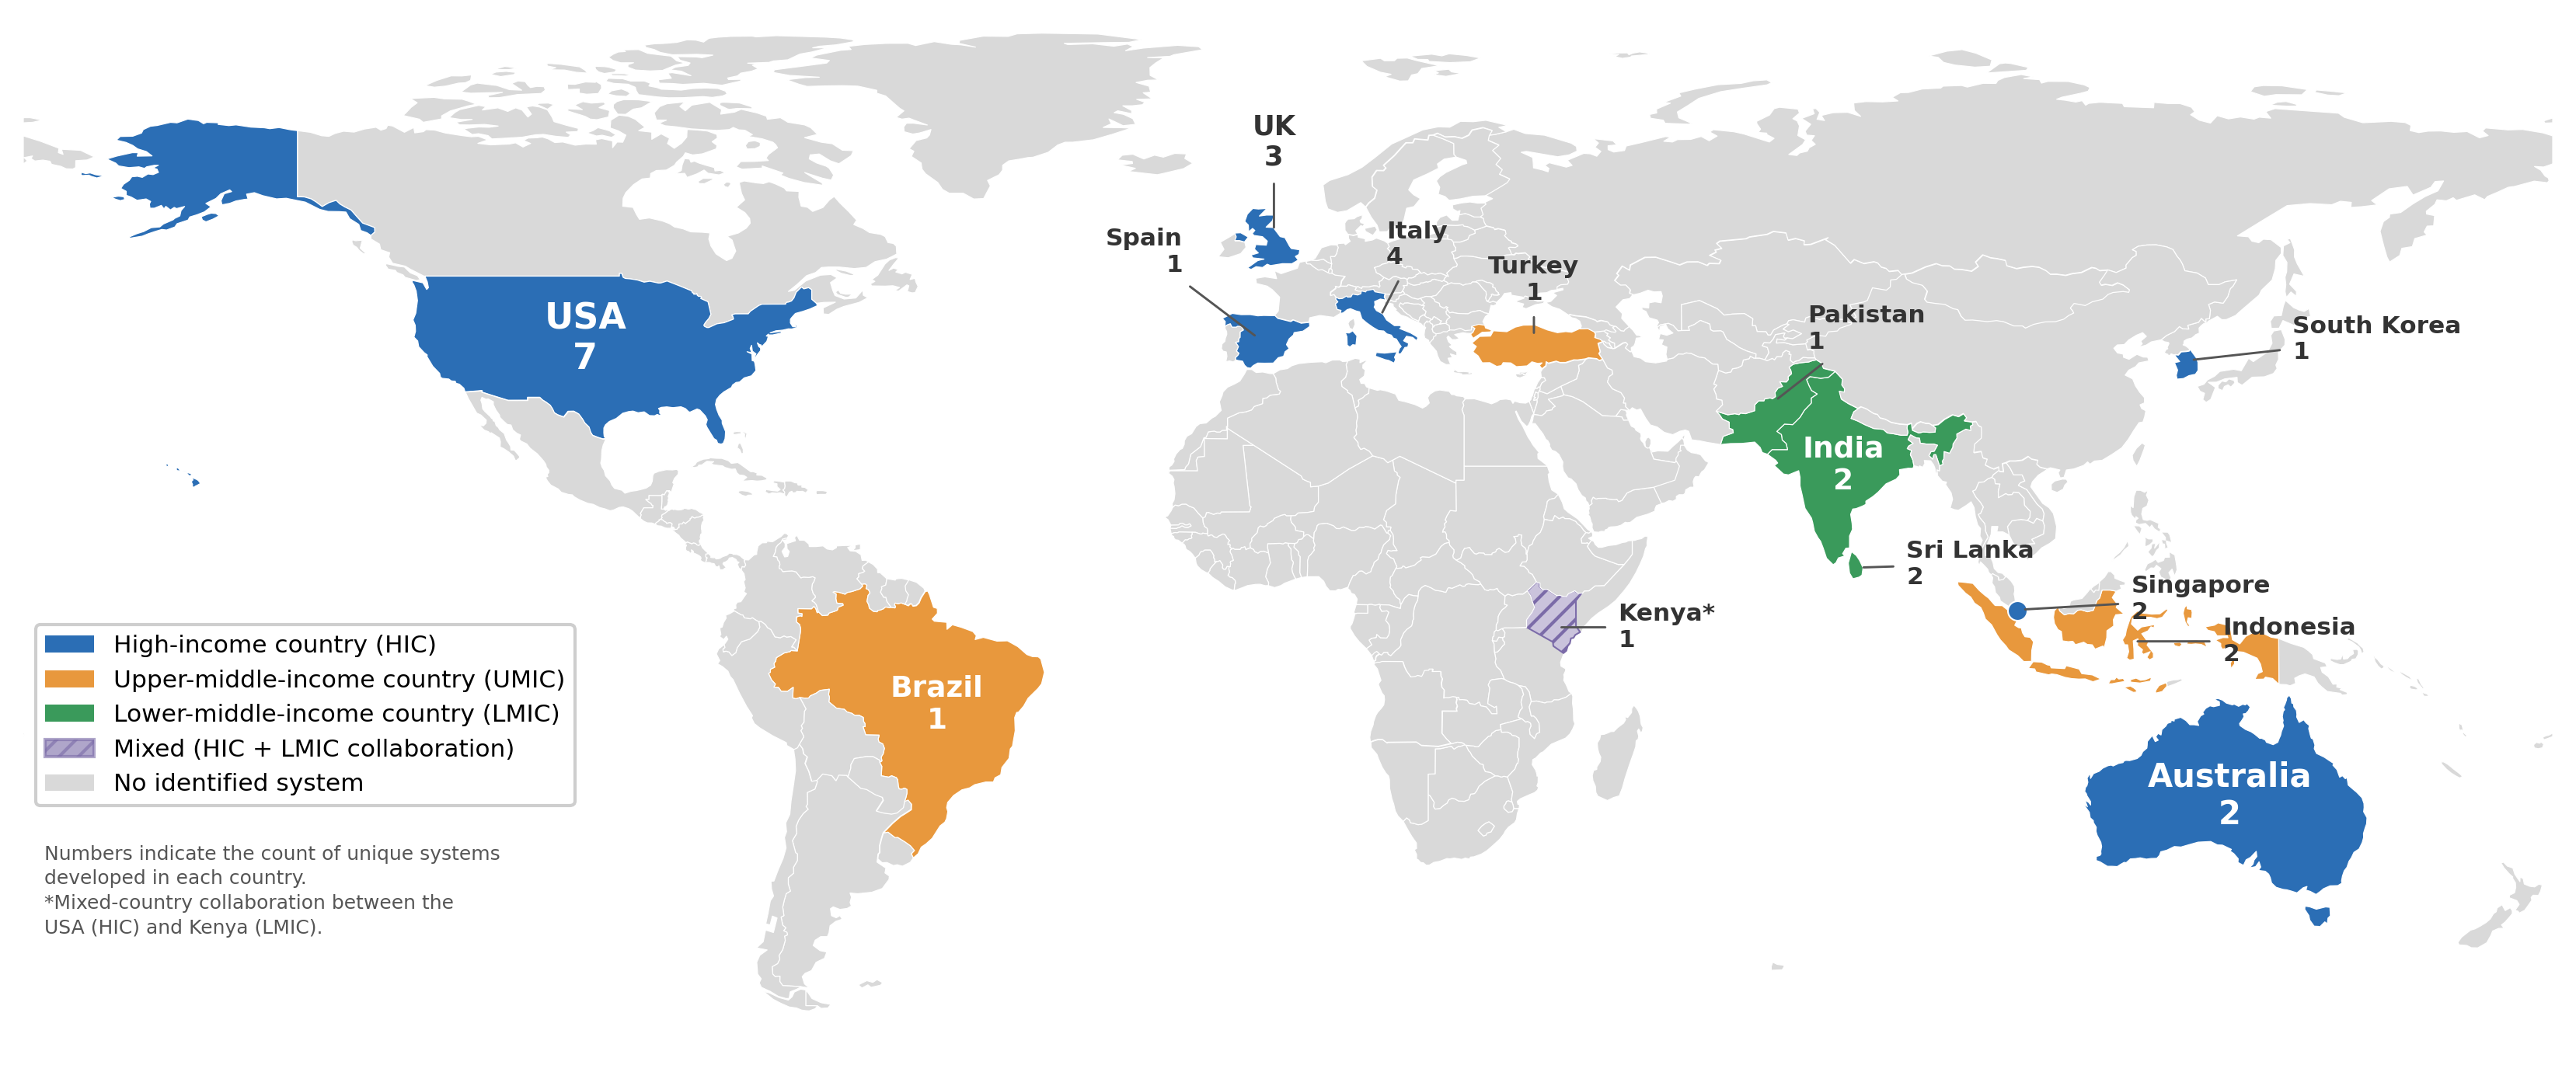

In [ ]:
"""
Geographic distribution of perinatal mental health CA development
(unique systems, n = 30), coloured by World Bank income group.
"""
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import geopandas as gpd
import numpy as np

# ---- LOAD WORLD ----
world = gpd.read_file("countries.geojson")

# ---- DATA ----
country_data = {
    "United States of America": (7, "HIC"),
    "United Kingdom":           (3, "HIC"),
    "Italy":                    (4, "HIC"),
    "Spain":                    (1, "HIC"),
    "Australia":                (2, "HIC"),
    "South Korea":              (1, "HIC"),
    "Turkey":                   (1, "UMIC"),
    "Brazil":                   (1, "UMIC"),
    "Indonesia":                (2, "UMIC"),
    "India":                    (2, "LMIC"),
    "Sri Lanka":                (2, "LMIC"),
    "Pakistan":                 (1, "LMIC"),
    "Kenya":                    (1, "Mixed"),
}
# Singapore not in 110m shapefile — handle as point marker
singapore = (2, "HIC", 103.8, 1.35)

colors = {
    "HIC":   "#2B6EB5",
    "UMIC":  "#E8983D",
    "LMIC":  "#3A9A5B",
    "Mixed": "#7B6BA8",
    "none":  "#D9D9D9",
}

# Assign colors
world["color"] = colors["none"]
world["income"] = "none"
for _, row in world.iterrows():
    name = row["ADMIN"]
    if name in country_data:
        _, income = country_data[name]
        world.loc[world["ADMIN"] == name, "color"] = colors[income]
        world.loc[world["ADMIN"] == name, "income"] = income

# ---- FIGURE ----
fig, ax = plt.subplots(figsize=(14, 7.5), dpi=300, facecolor="white")
ax.set_facecolor("white")

# Draw all countries
for _, row in world.iterrows():
    income = row["income"]
    if income == "Mixed":
        gpd.GeoSeries([row.geometry]).plot(ax=ax, color=colors["Mixed"], edgecolor="white",
                                           linewidth=0.3, alpha=0.4)
        gpd.GeoSeries([row.geometry]).plot(ax=ax, facecolor="none", edgecolor=colors["Mixed"],
                                           linewidth=0.5, hatch="////")
    else:
        gpd.GeoSeries([row.geometry]).plot(ax=ax, color=row["color"], edgecolor="white", linewidth=0.3)

# Singapore as colored circle (too small for polygon at 110m)
ax.plot(singapore[2], singapore[3], "o", color=colors["HIC"], markersize=6,
        markeredgecolor="white", markeredgewidth=0.5, zorder=10)

# ---- LABELS ----
label_config = [
    # (lon_text, lat_text, text, fontsize, ha, va, arrow_to_lon, arrow_to_lat)
    # All small countries get sharp straight leader lines
    (-2,   64,   "UK\n3",            8.5, "center", "bottom", -2, 55),
    (-15,  49,   "Spain\n1",         7.5, "right", "bottom", -4, 40),
    (14,   50,   "Italy\n4",         7.5, "left", "bottom", 13, 43),
    (35,   45,   "Turkey\n1",        7.5, "center", "bottom", 35, 40),
    (143,  40,   "South Korea\n1",   7.5, "left", "center", 128, 37),
    (120,   3,   "Singapore\n2",     7.5, "left", "center", 104, 1.5),
    (133,  -3,   "Indonesia\n2",     7.5, "left", "center", 120, -3),
    (88,    8,   "Sri Lanka\n2",     7.5, "left", "center", 81, 7.5),
    (74,   38,   "Pakistan\n1",      7.5, "left", "bottom", 69, 31),
    (47,   -1,   "Kenya*\n1",        7.5, "left", "center", 38, -1),
]

for item in label_config:
    tx, ty, text, fs, ha, va, ax2, ay2 = item
    if ax2 is not None:
        # Leader line
        ax.annotate(text, xy=(ax2, ay2), xytext=(tx, ty),
                    fontsize=fs, fontweight="bold", color="#333333",
                    ha=ha, va=va,
                    arrowprops=dict(arrowstyle="-", color="#555555", lw=0.7,
                                   connectionstyle="arc3,rad=0.0"),
                    zorder=15)
    else:
        ax.text(tx, ty, text, fontsize=fs, fontweight="bold", color="#333333",
                ha=ha, va=va, zorder=15)

# White text for large colored countries
for tx, ty, text, fs in [(-100, 40, "USA\n7", 11), (134, -25, "Australia\n2", 10),
                          (-50, -12, "Brazil\n1", 9), (79, 22, "India\n2", 9)]:
    ax.text(tx, ty, text, fontsize=fs, fontweight="bold", color="white",
            ha="center", va="center", zorder=16)

# Remove the black-text duplicates for these countries by drawing white over

# ---- AXES ----
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 85)
ax.set_aspect("equal")
ax.axis("off")


# ---- LEGEND ----
legend_items = [
    mpatches.Patch(facecolor=colors["HIC"], edgecolor="none", label="High-income country (HIC)"),
    mpatches.Patch(facecolor=colors["UMIC"], edgecolor="none", label="Upper-middle-income country (UMIC)"),
    mpatches.Patch(facecolor=colors["LMIC"], edgecolor="none", label="Lower-middle-income country (LMIC)"),
    mpatches.Patch(facecolor=colors["Mixed"], edgecolor=colors["Mixed"],
                   label="Mixed (HIC + LMIC collaboration)", hatch="////", alpha=0.6),
    mpatches.Patch(facecolor=colors["none"], edgecolor="none", label="No identified system"),
]
leg = ax.legend(handles=legend_items, loc="lower left", fontsize=7.5,
                frameon=True, framealpha=0.95, edgecolor="#CCCCCC",
                bbox_to_anchor=(0.0, 0.22))

# Footnotes
# Footnotes aligned directly under legend
ax.text(-177, -32,
        "Numbers indicate the count of unique systems\ndeveloped in each country.",
        fontsize=6, color="#555555", va="top", linespacing=1.4)
ax.text(-177, -39,
        "*Mixed-country collaboration between the\nUSA (HIC) and Kenya (LMIC).",
        fontsize=6, color="#555555", va="top", linespacing=1.4)


plt.savefig("fig_geography.png", bbox_inches="tight", dpi=300, facecolor="white")
plt.savefig("fig_geography.pdf", bbox_inches="tight", facecolor="white")
print("saved fig_geography.png / .pdf")

saved fig_pubtime.png / .pdf


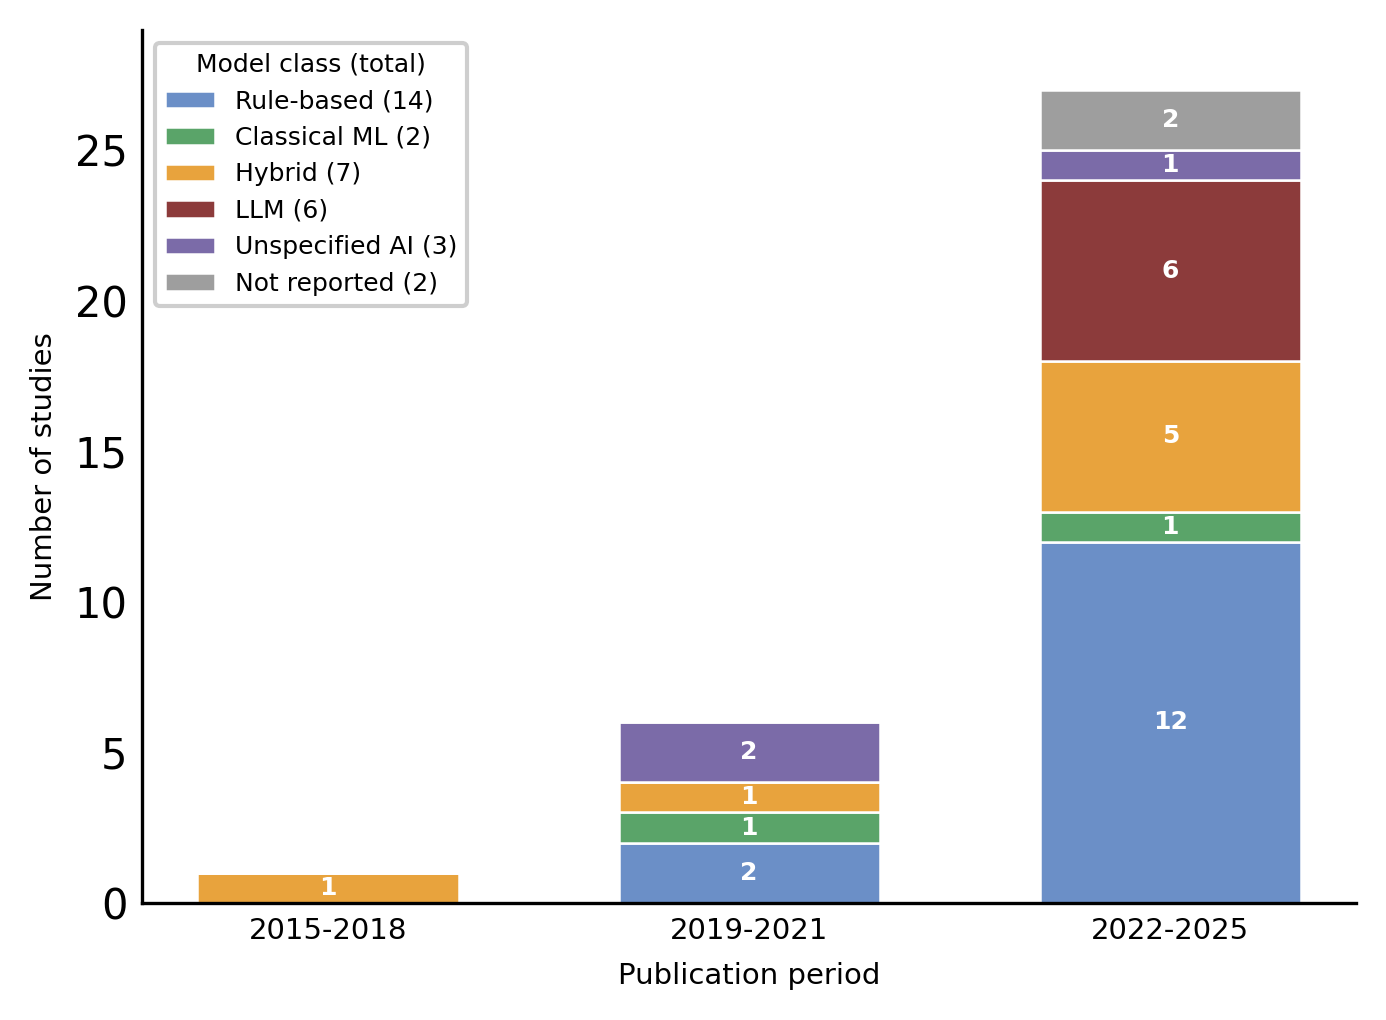

In [ ]:
"""
Publications over time by model class (N = 34 studies)
Stacked bar chart with non-overlapping publication periods.
"""
import matplotlib.pyplot as plt
import numpy as np

# ---- DATA: study ID -> (model class, year bin) ----
# Year bins: a=2015-2018, b=2019-2021, c=2022-2025
studies = {
    33: ("Hybrid", "a"),
    2:  ("Unspecified AI", "b"),
    3:  ("Unspecified AI", "b"),
    9:  ("Classical ML", "b"),
    18: ("Hybrid", "b"),
    23: ("Rule-based", "b"),
    32: ("Rule-based", "b"),
    1:  ("Rule-based", "c"),
    4:  ("Hybrid", "c"),
    5:  ("Rule-based", "c"),
    6:  ("LLM", "c"),
    7:  ("LLM", "c"),
    8:  ("Rule-based", "c"),
    10: ("Classical ML", "c"),
    11: ("LLM", "c"),
    12: ("LLM", "c"),
    13: ("Hybrid", "c"),
    14: ("Rule-based", "c"),
    15: ("Hybrid", "c"),
    16: ("Rule-based", "c"),
    17: ("Rule-based", "c"),
    19: ("Hybrid", "c"),
    20: ("LLM", "c"),
    21: ("Not reported", "c"),
    22: ("Rule-based", "c"),
    24: ("LLM", "c"),
    25: ("Not reported", "c"),
    26: ("Rule-based", "c"),
    27: ("Rule-based", "c"),
    28: ("Rule-based", "c"),
    29: ("Hybrid", "c"),
    30: ("Rule-based", "c"),
    31: ("Unspecified AI", "c"),
    34: ("Rule-based", "c"),
}

# ---- CONFIGURATION ----
periods = ["a", "b", "c"]
period_labels = ["2015-2018", "2019-2021", "2022-2025"]
classes = ["Rule-based", "Classical ML", "Hybrid", "LLM", "Unspecified AI", "Not reported"]
colors = {
    "Rule-based":      "#6B8FC7",
    "Classical ML":    "#5AA469",
    "Hybrid":          "#E8A33D",
    "LLM":             "#8C3B3B",
    "Unspecified AI":  "#7B6BA8",
    "Not reported":    "#9E9E9E",
}

# ---- COUNT MATRIX ----
counts = {c: [0, 0, 0] for c in classes}
for sid, (cls, period) in studies.items():
    counts[cls][periods.index(period)] += 1

# Verify totals
totals = {c: sum(counts[c]) for c in classes}
assert sum(totals.values()) == 34, f"Total studies = {sum(totals.values())}, expected 34"

# ---- FIGURE ----
fig, ax = plt.subplots(figsize=(4.72, 3.5), dpi=300)

x = np.arange(3)
bar_width = 0.62
bottom = np.zeros(3)

for cls in classes:
    vals = np.array(counts[cls])
    ax.bar(
        x, vals, bottom=bottom, width=bar_width,
        color=colors[cls],
        label=f"{cls} ({totals[cls]})",
        edgecolor="white", linewidth=0.6,
    )
    # Value labels inside each segment
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0:
            ax.text(
                xi, b + v / 2, str(int(v)),
                ha="center", va="center",
                fontsize=6, color="white", fontweight="bold",
            )
    bottom += vals

# Axes
ax.set_xticks(x)
ax.set_xticklabels(period_labels, fontsize=7)
ax.set_ylabel("Number of studies", fontsize=7)
ax.set_xlabel("Publication period", fontsize=7)
ax.set_ylim(0, 29)
ax.set_yticks(range(0, 30, 5))

# Title
#ax.set_title(
#    "Publications over time by model class (N = 34 studies)",
#    fontsize=6, fontweight="bold", pad=12,
#)

# Spines
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.tick_params(length=0)

# Legend
ax.legend(
    fontsize=6, loc="upper left",
    frameon=True, framealpha=0.95,
    title="Model class (total)", title_fontsize=6,
)

plt.tight_layout()
plt.savefig("fig_pubtime.png", bbox_inches="tight", dpi=300)
plt.savefig("fig_pubtime.pdf", bbox_inches="tight")
print("saved fig_pubtime.png / .pdf")

Dimension means: {'Privacy': 0.91, 'Safety': 1.56, 'Monitoring': 0.47, 'Regulation': 1.21, 'Bias & fairness': 1.97, 'Consent': 1.38}
saved fig_radar_corrected.png / .pdf


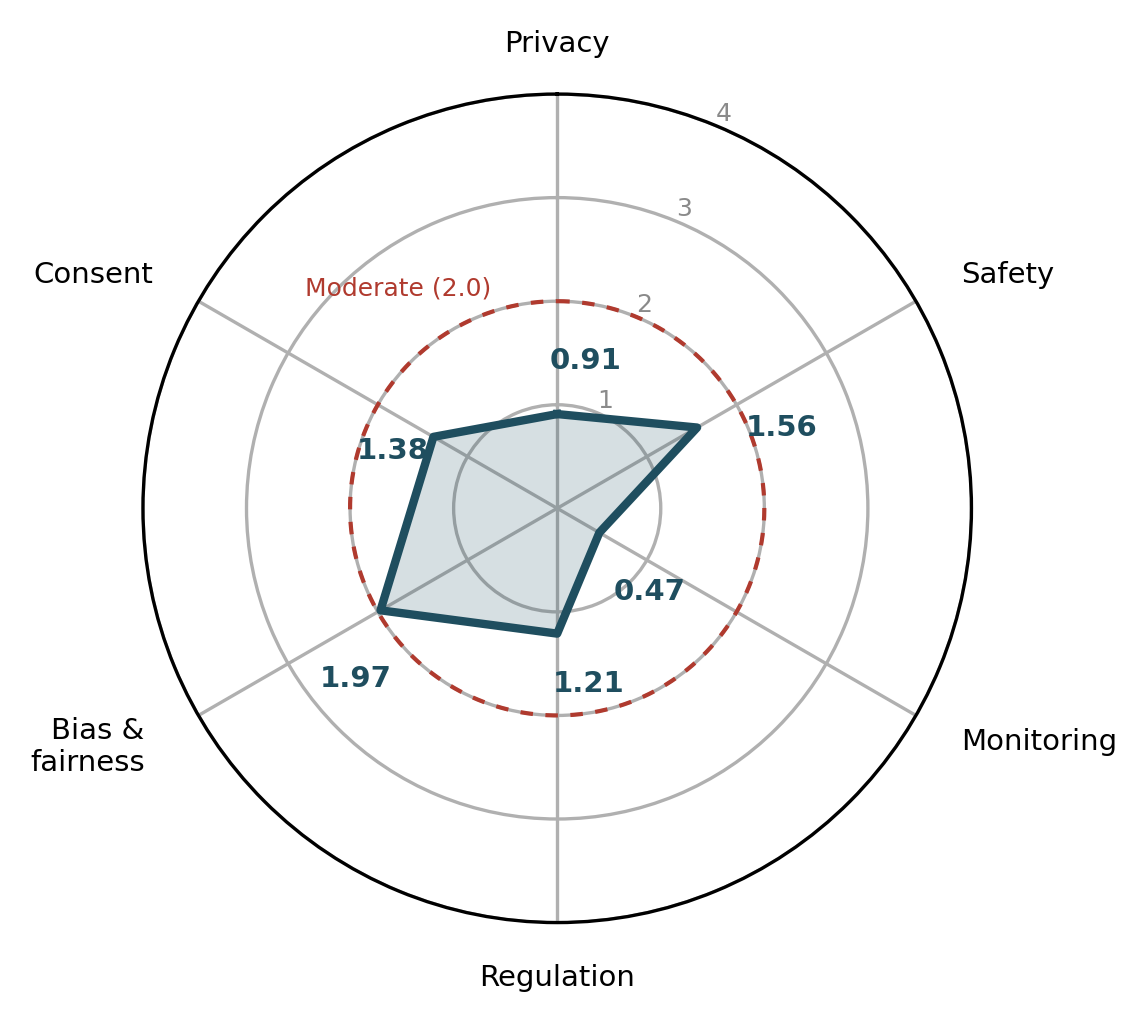

In [ ]:
"""
Governance Maturity Profile (Radar Chart)
Mean score per GMS dimension (0-4), across all 34 studies.
"""
import matplotlib.pyplot as plt
import numpy as np

# ---- DATA: verified per-study dimension scores ----
# (privacy, safety, monitoring, regulation, bias, consent)
dims = {
    1:  (2,2,0,2,2,3),  2:  (2,3,2,2,3,2),  3:  (0,1,0,0,1,0),  4:  (1,1,0,0,2,0),
    5:  (0,3,1,2,3,2),  6:  (0,2,1,0,1,0),  7:  (1,1,1,3,2,2),  8:  (0,3,0,1,2,2),
    9:  (0,2,0,0,2,0),  10: (0,2,0,0,2,0),  11: (0,1,0,1,3,2),  12: (0,0,0,1,3,3),
    13: (0,2,0,0,1,0),  14: (2,2,1,2,2,2),  15: (0,3,0,0,0,0),  16: (2,1,0,3,2,3),
    17: (2,3,1,2,2,2),  18: (0,2,0,1,2,0),  19: (0,1,1,2,1,2),  20: (0,0,0,0,2,1),
    21: (1,1,0,0,3,0),  22: (2,2,1,3,2,4),  23: (0,0,1,2,3,2),  24: (2,0,1,0,3,0),
    25: (0,0,0,3,1,2),  26: (2,1,1,3,2,4),  27: (1,2,0,1,3,2),  28: (2,0,1,1,3,1),
    29: (2,3,2,2,2,3),  30: (1,3,0,4,2,0),  31: (2,0,1,0,2,1),  32: (3,2,0,0,0,0),
    33: (1,2,0,0,0,2),  34: (0,2,0,0,3,0),
}
# tuple order: (privacy, safety, monitoring, regulation, bias, consent)

labels = ["Privacy", "Safety", "Monitoring", "Regulation", "Bias &\nfairness", "Consent"]
means = [round(np.mean([dims[s][d] for s in dims]), 2) for d in range(6)]
print("Dimension means:", dict(zip([l.replace('\n',' ') for l in labels], means)))
assert sum(sum(v) for v in dims.values()) == 255, "grid total mismatch"

N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
vals = means + means[:1]
angles2 = angles + angles[:1]

fig, ax = plt.subplots(figsize=(3.9, 3.9), subplot_kw=dict(polar=True), dpi=300)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_ylim(0, 4)

# radial gridlines/labels UNDER the data; keep the "1" ring tick away from the top vertex
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["1", "2", "3", "4"], fontsize=6, color="#8a8a8a")
ax.tick_params(axis='y', pad=0)
ax.set_xticks(angles)
ax.set_xticklabels([])
ax.set_axisbelow(True)

# dimension name labels (outside the outer ring)
label_positions = [
    (angles[0], 4.35, "Privacy",          "center", "bottom"),
    (angles[1], 4.5,  "Safety",           "left",   "center"),
    (angles[2], 4.5,  "Monitoring",       "left",   "center"),
    (angles[3], 4.4,  "Regulation",       "center", "top"),
    (angles[4], 4.6,  "Bias &\nfairness", "right",  "center"),
    (angles[5], 4.5,  "Consent",          "right",  "center"),
]
for angle, r, lbl, ha, va in label_positions:
    ax.text(angle, r, lbl, ha=ha, va=va, fontsize=7, fontweight="medium")

# Moderate threshold ring FIRST (so value labels sit on top of it)
theta_ring = np.linspace(0, 2 * np.pi, 200)
ax.plot(theta_ring, [2.0] * 200, linestyle=(0, (3, 3)), color="#B03A2E", linewidth=1, zorder=3)
ax.text(np.deg2rad(324), 2.62, "Moderate (2.0)", color="#B03A2E", fontsize=6, ha="center", va="center", zorder=4)

# profile polygon
ax.plot(angles2, vals, color="#1F4E5F", linewidth=2, zorder=5)
ax.fill(angles2, vals, color="#1F4E5F", alpha=0.18, zorder=2)

# value labels: nudged into the empty wedge BETWEEN spokes (angular offset) and set
# just outside each vertex, so no label overlaps a spoke, ring, or the profile line.
# No halo is used, so every gridline stays fully continuous.
half = np.pi / N                      # half the angular gap between adjacent spokes
# Each label: angular shift into the empty wedge (off the spokes) + a hand-tuned
# radius that avoids the 1/2/3 ring circles. No halo, so gridlines stay continuous.
place = [  # (angular shift, radius)
    ( +0.36*half, 1.45),   # Privacy    (0.91) -> between rings 1 and 2
    ( +0.34*half, 2.30),   # Safety     (1.56) -> outside ring 2
    ( +0.40*half, 1.20),   # Monitoring (0.47) -> between rings 1 and 2, off the spoke
    ( -0.34*half, 1.72),   # Regulation (1.21) -> between rings 1 and 2
    ( -0.34*half, 2.55),   # Bias&fair  (1.97) -> outside ring 2
    ( -0.36*half, 1.68),   # Consent    (1.38) -> between rings 1 and 2
]
for a, v, (sh, r) in zip(angles, means, place):
    ax.text(a + sh, r, f"{v:.2f}", ha="center", va="center",
            fontsize=7, color="#1F4E5F", fontweight="bold", zorder=6)

#ax.set_title("Governance Maturity Profile (mean score per dimension, 0-4)",
#             fontsize=6.5, pad=20, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_radar_corrected.png", bbox_inches="tight", dpi=300)
plt.savefig("fig_radar_corrected.pdf", bbox_inches="tight")
print("saved fig_radar_corrected.png / .pdf")

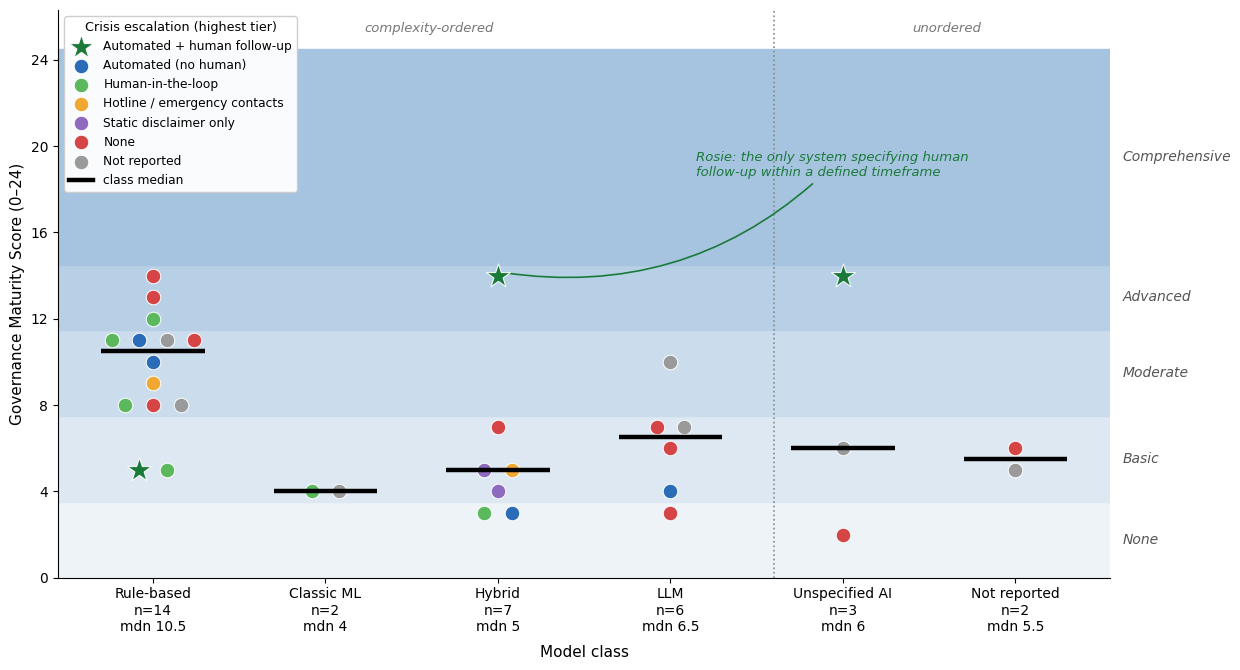

In [ ]:

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from collections import Counter

data = {
 "Rule-based":[(1,11,"HIL"),(5,11,"AUTO"),(8,8,"HIL"),(14,11,"NR"),(16,11,"NONE"),
               (17,12,"HIL"),(22,14,"NONE"),(23,8,"NONE"),(26,13,"NONE"),(27,9,"HOT"),
               (28,8,"NR"),(30,10,"AUTO"),(32,5,"AH"),(34,5,"HIL")],
 "Classic ML":[(9,4,"HIL"),(10,4,"NR")],
 "Hybrid":[(4,4,"DISC"),(13,3,"HIL"),(15,3,"AUTO"),(18,5,"DISC"),(19,7,"NONE"),
           (29,14,"AH"),(33,5,"HOT")],
 "LLM":[(6,4,"AUTO"),(7,10,"NR"),(11,7,"NONE"),(12,7,"NR"),(20,3,"NONE"),(24,6,"NONE")],
 "Unspecified AI":[(2,14,"AH"),(3,2,"NONE"),(31,6,"NR")],
 "Not reported":[(21,5,"NR"),(25,6,"NONE")],
}

tier_style = {
 "AH":  dict(c="#1a7a3a", marker="*", s=330, label="Automated + human follow-up", z=6),
 "AUTO":dict(c="#2b6cb8", marker="o", s=110, label="Automated (no human)",        z=5),
 "HIL": dict(c="#5cb85c", marker="o", s=110, label="Human-in-the-loop",           z=5),
 "HOT": dict(c="#f0a832", marker="o", s=110, label="Hotline / emergency contacts",z=5),
 "DISC":dict(c="#8e6bbf", marker="o", s=110, label="Static disclaimer only",      z=5),
 "NONE":dict(c="#d64545", marker="o", s=110, label="None",                        z=5),
 "NR":  dict(c="#9a9a9a", marker="o", s=110, label="Not reported",                z=5),
}

fig, ax = plt.subplots(figsize=(12.5, 6.8))
bands  = [(0,3.5,"None"),(3.5,7.5,"Basic"),(7.5,11.5,"Moderate"),
          (11.5,14.5,"Advanced"),(14.5,24.5,"Comprehensive")]
shades = ["#eef3f8","#dde8f2","#cbdcec","#b8d0e6","#a6c4e0"]
for (lo,hi,lab),sh in zip(bands,shades):
    ax.axhspan(lo,hi,color=sh,zorder=0)
    ax.text(5.62,(lo+min(hi,24.5))/2,lab,fontsize=10,style="italic",color="#555",va="center")
    
classes=list(data.keys()); seen=set()
for xi,cl in enumerate(classes):
    pts=data[cl]; ys=[p[1] for p in pts]
    cnt=Counter(ys); off={}
    xs=[]
    for s,y,t in pts:
        k=cnt[y]; i=off.get(y,0); off[y]=i+1
        xs.append(xi+(0 if k==1 else (i-(k-1)/2)*0.16))
    for (s,y,t),x in zip(pts,xs):
        st=tier_style[t]
        lab=st["label"] if st["label"] not in seen else None
        seen.add(st["label"])
        ax.scatter(x,y,c=st["c"],marker=st["marker"],s=st["s"],label=lab,
                   zorder=st["z"],edgecolors="white",linewidths=0.7)
    ax.hlines(np.median(ys),xi-0.3,xi+0.3,color="black",lw=3.2,zorder=7)
ax.axvline(3.6,color="#888",ls=":",lw=1.2)
ax.text(1.6,25.3,"complexity-ordered",fontsize=9.5,color="#777",style="italic",ha="center")
ax.text(4.6,25.3,"unordered",fontsize=9.5,color="#777",style="italic",ha="center")
meds={cl:np.median([p[1] for p in data[cl]]) for cl in classes}
ax.set_xticks(range(len(classes)))
ax.set_xticklabels([f"{cl}\nn={len(data[cl])}\nmdn {meds[cl]:g}" for cl in classes],fontsize=10)
ax.set_ylim(0,26.3); ax.set_yticks(range(0,25,4)); ax.set_xlim(-0.55,5.55)
ax.set_ylabel("Governance Maturity Score (0\u201324)",fontsize=11)
ax.set_xlabel("Model class",fontsize=11,labelpad=8)
ax.annotate("Rosie: the only system specifying human\nfollow-up within a defined timeframe",
            xy=(2.02,14.15),xytext=(3.15,18.6),fontsize=9.5,color="#1a7a3a",style="italic",
            arrowprops=dict(arrowstyle="-",color="#1a7a3a",lw=1.2,
                            connectionstyle="arc3,rad=-0.25"))

order=["Automated + human follow-up","Automated (no human)","Human-in-the-loop",
       "Hotline / emergency contacts","Static disclaimer only","None","Not reported"]
handles,labs=ax.get_legend_handles_labels(); hl=dict(zip(labs,handles))
med_h=mlines.Line2D([],[],color="black",lw=3.2,label="class median")
ax.legend([hl[o] for o in order]+[med_h],order+["class median"],loc="upper left",
          fontsize=8.8,title="Crisis escalation (highest tier)",title_fontsize=9.2,framealpha=0.95)

for sp in ["top","right"]: ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig("Fig5_safety_autonomy.png",dpi=300,bbox_inches="tight")
plt.show()
